<h1>Assignment 3: <strong> Regularization and Optimization</strong></h1>
Name : Sammit Poudyal <br/>
Class : CE 2022<br/>
Registration Number : 032329-22<br>
Date : 18/04/2026<br/>
Dataset Used :<strong> CIFAR-10 </strong><br/>


## 1. Objectives
- Show how a high‑capacity network overfits on CIFAR‑10 and measure the train vs validation performance gap.
- Compare how L1 penalty, L2 weight decay, and Dropout affect generalization and final test accuracy.
- Evaluate convergence speed, training stability, and bias‑variance trade‑offs between SGD (with momentum) and Adam.
- Generate reproducible loss curves and metric tables to clearly isolate the impact of each regularization and optimization choice.


## 2. Theoretical Background

### 2.1 Overfitting
When a model recalls every detail of its training - noise included - it often fails to grasp broader trends. Memorization kicks in, yet real understanding slips away. Patterns get lost because too much focus lands on exact examples. Instead of seeing the bigger picture, it fixates on small quirks. Learning becomes rigid once details outweigh rules. General skills fade if precision takes full control. What looks like progress might just be mimicry without meaning.
- Symptom: Training loss keeps dropping but validation loss stops improving or gets worse. 
Too much detail learned by a model gets tamed through simpler rules built into training. Complexity takes a back seat when penalties shape learning. These adjustments keep predictions closer to real patterns. Over time, wild guesses fade under tighter control. Learning stays focused without memorizing noise.

### 2.2 Regularization Techniques
L2 Regularization is also known as Weight Decay.
- Adds a penalty for large weights:
$$L_{\text{total}} = L_{\text{CE}} + \lambda \sum w_i^2$$
It smoothes the choices by nudging weights down, so the model handles new data more reliably. Lighter values create gentler shifts across decisions, avoiding harsh jumps. This softness helps performance stay strong outside training. Less extreme numbers mean fewer surprises when facing unknown examples.
- In PyTorch: `weight_decay` argument in optimizer.

L1 Regularization
- Penalizes absolute weight values:
$$L_{\text{total}} = L_{\text{CE}} + \lambda \sum |w_i|$$
Zeroing out plenty of coefficients happens here, thanks to its built-in shrinkage. Features get quietly dropped when they don’t add value.

Dropout
Some neurons get switched off now and then when learning happens, about p out of every hundred.
Here is why it works. Neurons stop relying on each other when they cannot team up too closely during training. This setup pushes the system to develop backup ways of recognizing patterns. When tested later, every neuron joins in - just scaled down a bit to keep things balanced.
- In PyTorch: `nn.Dropout(p)`.

Batch Normalization
- Normalizes layer outputs over each mini‑batch:
Start with x minus the batch mean. Divided by that comes next. The square root holds variance plus a small constant. Denominator stops division by zero. Normalized value appears after all steps finish
Smaller shifts during updates help keep learning steady. Higher learning speeds become possible because of this balance. A touch of randomness sneaks in, just enough to gently prevent overfitting.

2.3 Optimizers

SGD with Momentum
- Vanilla SGD: $\theta \leftarrow \theta - \eta \nabla_\theta L$
Sliding along earlier slopes helps ease adjustments later. Each step leans on what came before, guiding changes without abrupt shifts
Speed builds using past momentum plus a push from the loss slope, then weights shift against that combined step.
Most of the time, it lands on smoother low points that work well on new data
One hurdle stands out. Getting the learning rate right takes patience. Wrong settings slow progress. Success hinges on precise adjustments. Trial often leads to error. Fine control separates results. Each attempt teaches something new.

Adam
Each setting adjusts its own pace by remembering past steps. One moment guides how fast things change next time. Speed depends on what happened before, not a fixed rule. Past movement shapes future updates differently each round
At time t, the value of m depends on its previous state multiplied by β₁ - then add a piece of current gradient scaled by one minus beta one
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$\theta \leftarrow \theta - \eta \frac{m_t}{\sqrt{v_t} + \epsilon}$$
Fast convergence stands out. Default settings handle most cases without tweaks
Some models might get stuck near sharper low points. This can lead to less consistent performance on new data at times.

2.4 Signs of Overfitting in Models
- Plot training loss and validation loss over epochs.
When a model learns too much detail, its performance on new data gets worse even if training improves. Mistaking noise for patterns causes errors later. The gap between practice and real-world results widens. Learning too closely means missing the bigger picture. Progress during study doesn’t guarantee success afterward.
When things go well, the two losses stick near each other while the validation number stays down.

## 3. Dataset Description
- Source: `torchvision.datasets.CIFAR10`
- Samples: 60,000 colour images (32×32) in 10 classes.
- Features: 3,072 pixel values per image (flattened for MLP).
- Preprocessing: Convert to tensor, normalising with  
 $\mu = [0.4914, 0.4822, 0.4465]$, $\sigma = [0.2470, 0.2435, 0.2616]$.
- Split: 45k train / 5k validation (stratified, fixed seed) / 10k test.

## 4. Implementation

### 4.1 Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from collections import defaultdict
import time
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(77)
np.random.seed(77)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Using device: cpu


### 4.2 Downloading Dataset

In [2]:
# CIFAR-100 normalization constants (computed from the full training set)
mean_c100 = (0.5071, 0.4867, 0.4408)
std_c100  = (0.2675, 0.2565, 0.2761)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_c100, std_c100)
])

# Download datasets
full_train = datasets.CIFAR100(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

# 45k train / 5k validation (fixed seed for reproducibility)
train_subset, val_subset = random_split(
    full_train, [45000, 5000],
    generator=torch.Generator().manual_seed(42)
)

BATCH = 128
train_loader = DataLoader(train_subset, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_subset,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,    batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')


100%|██████████| 169M/169M [01:28<00:00, 1.90MB/s]   


Train batches: 352 | Val batches: 40 | Test batches: 79


### 4.3 CIFAR-100 Class & Superclass Names

In [3]:
# 100 fine-grained class names (ordered by class index 0-99)
FINE_CLASSES = [
    'apple','aquarium_fish','baby','bear','beaver','bed','bee','beetle','bicycle','bottle',
    'bowl','boy','bridge','bus','butterfly','camel','can','castle','caterpillar','cattle',
    'chair','chimpanzee','clock','cloud','cockroach','couch','crab','crocodile','cup','dinosaur',
    'dolphin','elephant','flatfish','forest','fox','girl','hamster','house','kangaroo','keyboard',
    'lamp','lawn_mower','leopard','lion','lizard','lobster','man','maple_tree','motorcycle','mountain',
    'mouse','mushroom','oak_tree','orange','orchid','otter','palm_tree','pear','pickup_truck','pine_tree',
    'plain','plate','poppy','porcupine','possum','rabbit','raccoon','ray','road','rocket',
    'rose','sea','seal','shark','shrew','skunk','skyscraper','snail','snake','spider',
    'squirrel','streetcar','sunflower','sweet_pepper','table','tank','telephone','television','tiger','tractor',
    'train','trout','tulip','turtle','wardrobe','whale','willow_tree','wolf','woman','worm'
]

# 20 superclass names (each covers 5 fine-grained classes)
SUPER_CLASSES = [
    'aquatic_mammals','fish','flowers','food_containers','fruit_and_vegetables',
    'household_electrical_devices','household_furniture','insects','large_carnivores',
    'large_man-made_outdoor','large_natural_outdoor','large_omnivores_herbivores',
    'medium-sized_mammals','non-insect_invertebrates','people','reptiles',
    'small_mammals','trees','vehicles_1','vehicles_2'
]

# Mapping: fine class index → superclass index
# (official CIFAR-100 coarse labels order)
FINE_TO_SUPER = [
    4, 1, 14, 8, 0, 6, 7, 7, 18, 3,
    3, 14, 9, 18, 7, 11, 3, 9, 7, 11,
    6, 11, 5, 10, 7, 6, 13, 15, 3, 15,
    0, 11, 1, 10, 12, 14, 16, 9, 11, 5,
    5, 19, 8, 8, 15, 13, 14, 17, 18, 10,
    16, 4, 17, 4, 2, 0, 17, 4, 18, 17,
    10, 3, 2, 12, 12, 16, 12, 1, 9, 19,
    2, 10, 0, 1, 16, 12, 9, 13, 15, 13,
    16, 18, 2, 4, 6, 19, 5, 5, 8, 19,
    18, 1, 2, 15, 6, 0, 17, 8, 14, 13
]

print(f'Fine classes: {len(FINE_CLASSES)}')
print(f'Superclasses: {len(SUPER_CLASSES)}')
print(f'Sample fine→super mappings:')
for idx in [0, 1, 14, 48, 99]:
    print(f'  [{idx:3d}] {FINE_CLASSES[idx]:<25} → {SUPER_CLASSES[FINE_TO_SUPER[idx]]}')


Fine classes: 100
Superclasses: 20
Sample fine→super mappings:
  [  0] apple                     → fruit_and_vegetables
  [  1] aquarium_fish             → fish
  [ 14] butterfly                 → insects
  [ 48] motorcycle                → vehicles_1
  [ 99] worm                      → non-insect_invertebrates


## 4.3 Dataset Visualization

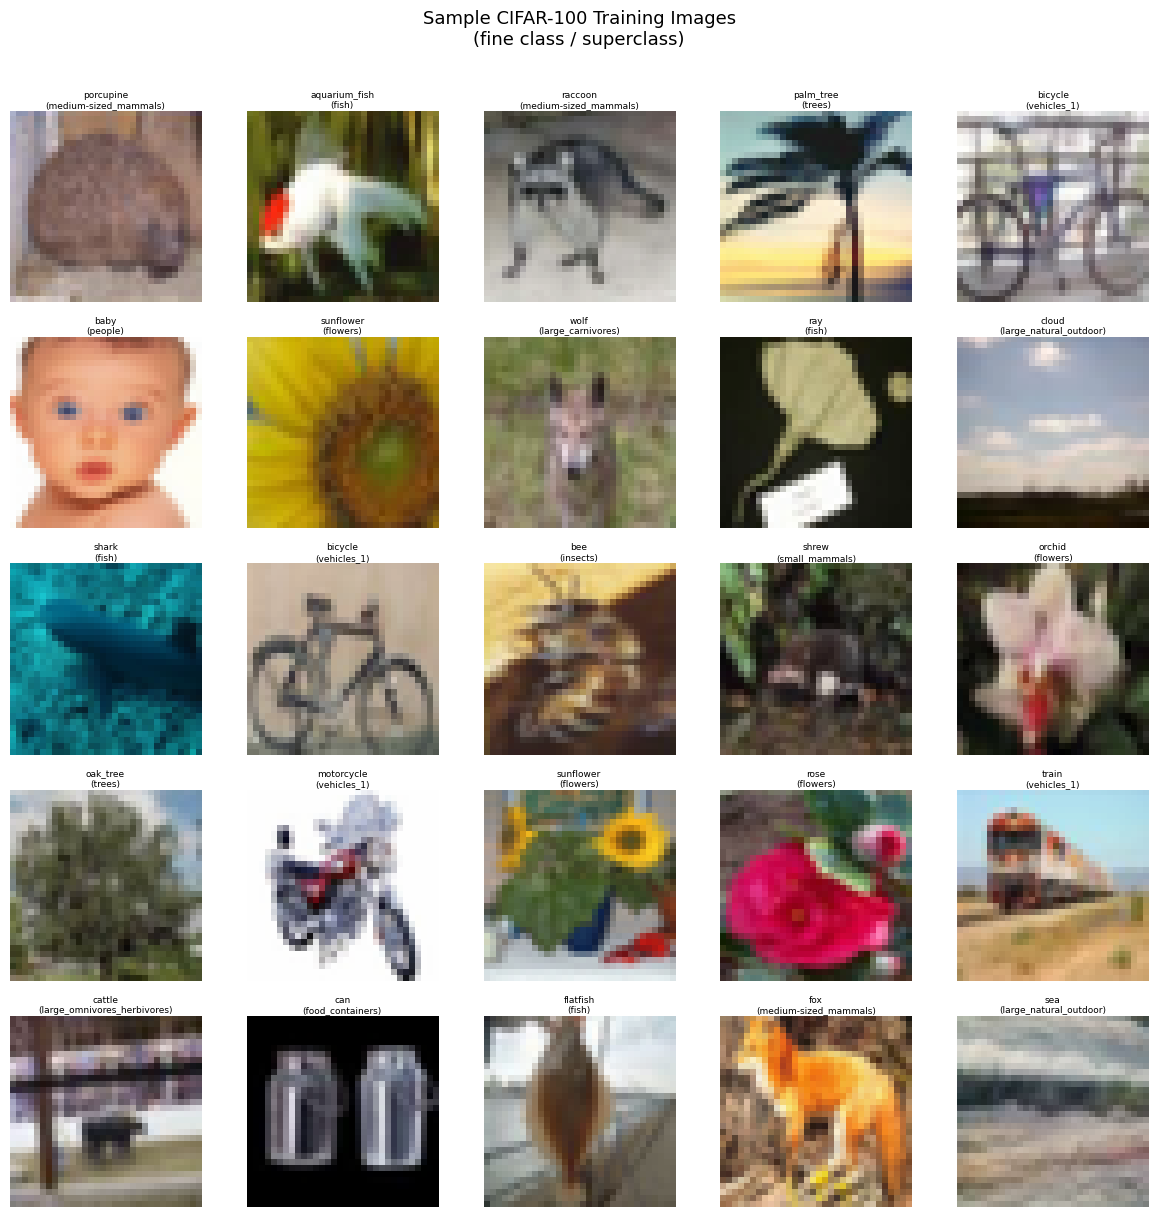

In [4]:
def denorm(img_tensor):
    """Convert a normalised tensor to a displayable numpy image."""
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = np.array(std_c100) * img + np.array(mean_c100)
    return np.clip(img, 0, 1)

# ── Grid of 25 random training images ──
data_iter = iter(train_loader)
images, labels = next(data_iter)

plt.figure(figsize=(12, 12))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(denorm(images[i]))
    lbl = labels[i].item()
    plt.title(f'{FINE_CLASSES[lbl]}\n({SUPER_CLASSES[FINE_TO_SUPER[lbl]]})',
              fontsize=6.5, pad=2)
    plt.axis('off')
plt.suptitle('Sample CIFAR-100 Training Images\n(fine class / superclass)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


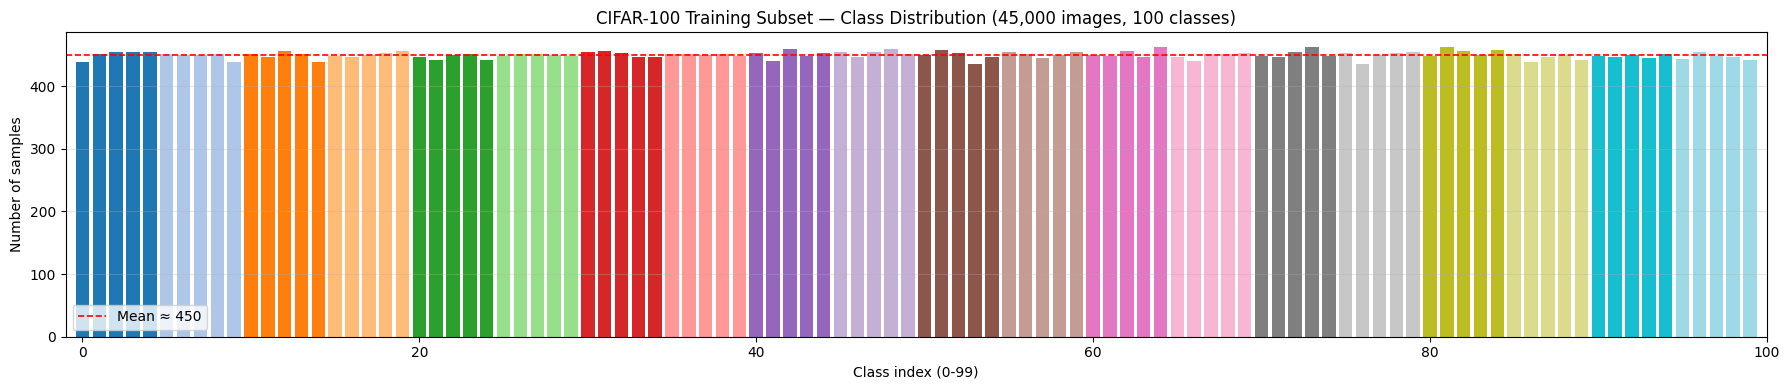

Samples per class → min: 435, max: 463, mean: 450.0


In [5]:
# ── Class-distribution bar chart (training subset) ──
train_labels = [full_train.targets[i] for i in train_subset.indices]
unique, counts = np.unique(train_labels, return_counts=True)

plt.figure(figsize=(18, 4))
bars = plt.bar(unique, counts, color=plt.cm.tab20(unique / 100), width=0.8)
plt.xlabel('Class index (0-99)')
plt.ylabel('Number of samples')
plt.title('CIFAR-100 Training Subset — Class Distribution (45,000 images, 100 classes)')
plt.xlim(-1, 100)
plt.axhline(counts.mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean ≈ {counts.mean():.0f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Samples per class → min: {counts.min()}, max: {counts.max()}, mean: {counts.mean():.1f}')


### 4.3 Model Creation

In [6]:
def create_mlp_model(
    input_dim    = 3 * 32 * 32,   # 3072 flattened pixels
    hidden_dims  = [1024, 512, 256],
    num_classes  = 100,            # CIFAR-100 has 100 classes
    dropout_rate = 0.0,
    use_batchnorm= True
):
    """
    3-hidden-layer MLP for CIFAR-100.
    Architecture: 3072 → 1024 → 512 → 256 → 100
    Optional: BatchNorm after each linear layer, Dropout before next layer.
    """
    layers = []
    prev = input_dim
    for h in hidden_dims:
        layers.append(nn.Linear(prev, h))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(h))
        layers.append(nn.ReLU(inplace=True))
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        prev = h
    layers.append(nn.Linear(prev, num_classes))
    return nn.Sequential(*layers)

# Print architecture
demo = create_mlp_model(dropout_rate=0.5, use_batchnorm=True)
print(demo)
total_params = sum(p.numel() for p in demo.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')


Sequential(
  (0): Linear(in_features=3072, out_features=1024, bias=True)
  (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=1024, out_features=512, bias=True)
  (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): Dropout(p=0.5, inplace=False)
  (8): Linear(in_features=512, out_features=256, bias=True)
  (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): Dropout(p=0.5, inplace=False)
  (12): Linear(in_features=256, out_features=100, bias=True)
)

Total trainable parameters: 3,832,164


### 4.4 Complete Helper Function

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device, l1_lambda=0.0):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device).view(images.size(0), -1)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        if l1_lambda > 0:
            l1 = sum(p.abs().sum() for p in model.parameters())
            loss = loss + l1_lambda * l1
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, pred = outputs.max(1)
        total   += labels.size(0)
        correct += pred.eq(labels).sum().item()
    return total_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device).view(images.size(0), -1)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, pred = outputs.max(1)
            total   += labels.size(0)
            correct += pred.eq(labels).sum().item()
    return total_loss / total, 100.0 * correct / total


### Experiments runner

In [8]:
def run_experiment(optimizer_name, reg_config, epochs=25, lr=0.01):
    """
    Train one model configuration and return its full history.
    Parameters
    ----------
    optimizer_name : 'sgd' or 'adam'
    reg_config     : dict with keys weight_decay, dropout_rate, l1_lambda
    epochs         : number of training epochs
    lr             : base learning rate
    """
    desc = (f"{optimizer_name.upper()} | lr={lr} | "
            f"L2={reg_config.get('weight_decay',0):.0e} | "
            f"L1={reg_config.get('l1_lambda',0):.0e} | "
            f"Dropout={reg_config.get('dropout_rate',0)}")
    print(f"\n{'='*65}")
    print(f" {desc}")
    print(f"{'='*65}")

    model = create_mlp_model(dropout_rate=reg_config.get('dropout_rate', 0.0)).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9,
                              weight_decay=reg_config.get('weight_decay', 0.0))
    elif optimizer_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr,
                               weight_decay=reg_config.get('weight_decay', 0.0))
    else:
        raise ValueError(f'Unknown optimizer: {optimizer_name}')

    # Cosine annealing: smoothly decays lr to near-zero over the run
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
    t0 = time.time()

    print(f"{'Epoch':<7}{'Train Loss':<13}{'Train Acc':<12}{'Val Loss':<13}{'Val Acc':<10}")
    print('-' * 58)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device,
            l1_lambda=reg_config.get('l1_lambda', 0.0)
        )
        vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f"{epoch:<7}{tr_loss:<13.4f}{tr_acc:<12.2f}{vl_loss:<13.4f}{vl_acc:<10.2f}")

    elapsed = time.time() - t0
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    print('-' * 58)
    print(f"Test Loss: {test_loss:.4f}  |  Test Acc: {test_acc:.2f}%  |  Time: {elapsed:.0f}s")

    return {
        'history'  : history,
        'test_loss': test_loss,
        'test_acc' : test_acc,
        'time'     : elapsed,
        'model'    : model,
        'desc'     : desc
    }


## 5.Experiments

Six configurations will be compared:
1. Baseline (SGD, no regularization)
2. L2 Weight Decay (SGD, λ=1e-4)
3. L1 Regularization (SGD, λ=1e-5)
4. Dropout (SGD, p=0.5)
5. Adam (Dropout + L2)
6. SGD (Dropout + L2)

In [9]:
EPOCHS = 25

configs = {
    'baseline_sgd': {
        'optimizer': 'sgd',  'lr': 0.01,
        'reg': {'weight_decay': 0.0,  'dropout_rate': 0.0, 'l1_lambda': 0.0}
    },
    'l2_reg_sgd': {
        'optimizer': 'sgd',  'lr': 0.01,
        'reg': {'weight_decay': 1e-4, 'dropout_rate': 0.0, 'l1_lambda': 0.0}
    },
    'l1_reg_sgd': {
        'optimizer': 'sgd',  'lr': 0.01,
        # λ=1e-4 is large enough to observe sparsity on 3072-dim input
        'reg': {'weight_decay': 0.0,  'dropout_rate': 0.0, 'l1_lambda': 1e-4}
    },
    'dropout_sgd': {
        'optimizer': 'sgd',  'lr': 0.01,
        'reg': {'weight_decay': 0.0,  'dropout_rate': 0.5, 'l1_lambda': 0.0}
    },
    'adam_combined': {
        'optimizer': 'adam', 'lr': 0.001,   # Adam uses a lower base lr
        'reg': {'weight_decay': 1e-4, 'dropout_rate': 0.5, 'l1_lambda': 0.0}
    },
    'sgd_combined': {
        'optimizer': 'sgd',  'lr': 0.01,
        'reg': {'weight_decay': 1e-4, 'dropout_rate': 0.5, 'l1_lambda': 0.0}
    },
}

experiment_results = {}
for name, cfg in configs.items():
    experiment_results[name] = run_experiment(
        optimizer_name = cfg['optimizer'],
        reg_config     = cfg['reg'],
        epochs         = EPOCHS,
        lr             = cfg['lr']
    )



 SGD | lr=0.01 | L2=0e+00 | L1=0e+00 | Dropout=0.0
Epoch  Train Loss   Train Acc   Val Loss     Val Acc   
----------------------------------------------------------
1      3.7506       14.08       3.4014       19.84     
5      2.6241       33.69       3.0775       26.26     
10     1.6825       55.42       3.2660       26.68     
15     0.7033       82.78       3.6329       27.82     
20     0.1985       97.20       3.8800       27.76     
25     0.1224       99.00       3.8942       28.06     
----------------------------------------------------------
Test Loss: 3.8873  |  Test Acc: 28.36%  |  Time: 712s

 SGD | lr=0.01 | L2=1e-04 | L1=0e+00 | Dropout=0.0
Epoch  Train Loss   Train Acc   Val Loss     Val Acc   
----------------------------------------------------------
1      3.7532       14.15       3.3931       20.38     
5      2.6340       33.76       3.0426       26.54     
10     1.7070       54.78       3.2674       26.54     
15     0.7260       82.02       3.6451       27.0

## 6.Results

### 6.1 Train vs Validation Loss Curves

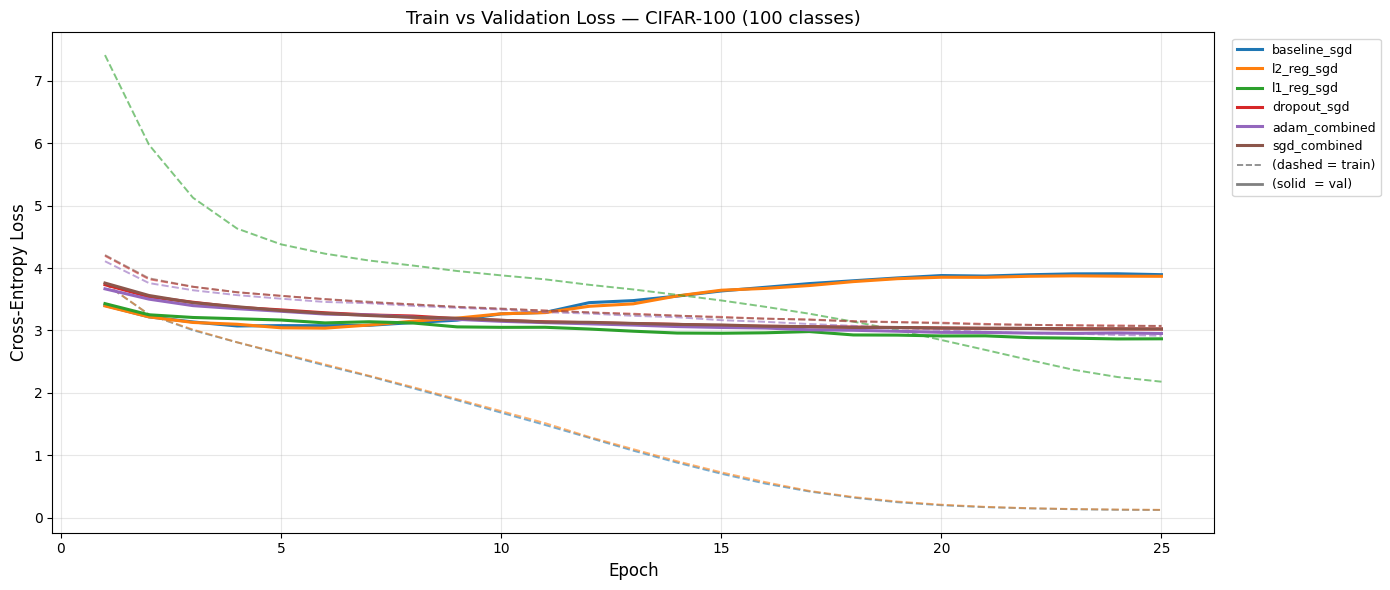

Saved: loss_curves.png


In [10]:
COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']
ep = list(range(1, EPOCHS + 1))

plt.figure(figsize=(14, 6))
for (name, res), color in zip(experiment_results.items(), COLORS):
    h = res['history']
    plt.plot(ep, h['train_loss'], '--', color=color, alpha=0.6, linewidth=1.4)
    plt.plot(ep, h['val_loss'],   '-',  color=color, linewidth=2.2, label=name)

# Dummy legend entries for line style
plt.plot([], '--', color='grey', linewidth=1.2, label='(dashed = train)')
plt.plot([], '-',  color='grey', linewidth=2.0, label='(solid  = val)')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.title('Train vs Validation Loss — CIFAR-100 (100 classes)', fontsize=13)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: loss_curves.png")


### 6.2 Train vs Validation Accuracy Curves

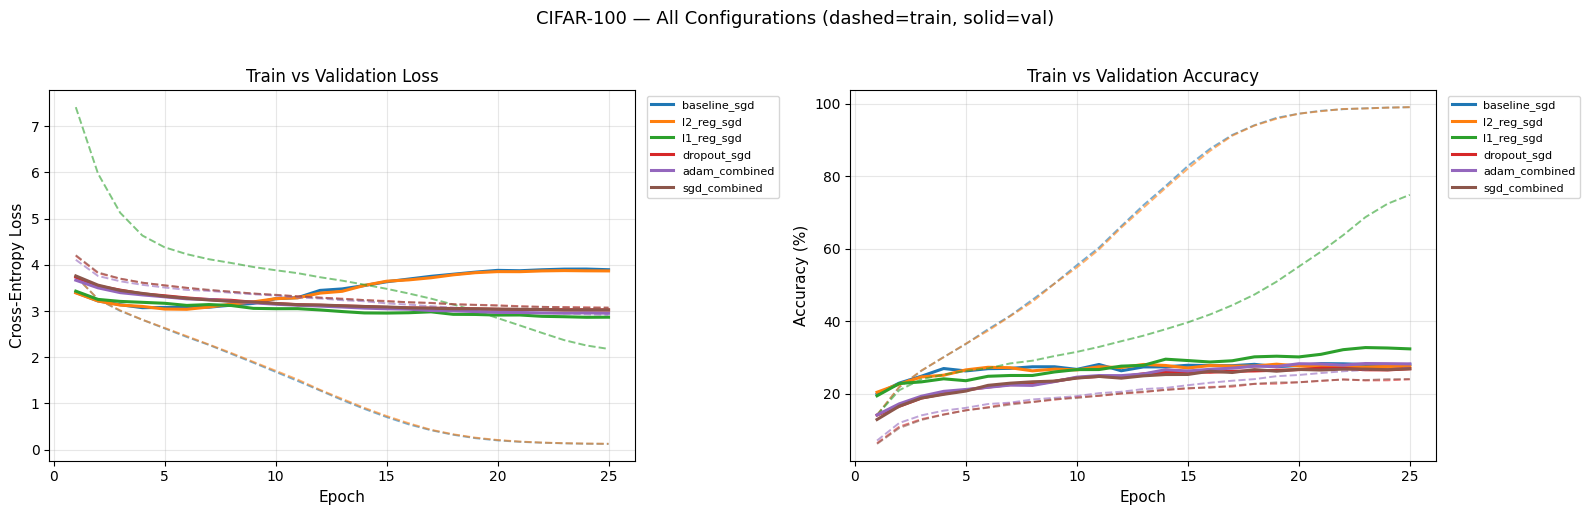

Saved: loss_acc_curves.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

for (name, res), color in zip(experiment_results.items(), COLORS):
    h = res['history']
    # Loss
    axes[0].plot(ep, h['train_loss'], '--', color=color, alpha=0.6, linewidth=1.4)
    axes[0].plot(ep, h['val_loss'],   '-',  color=color, linewidth=2.2, label=name)
    # Accuracy
    axes[1].plot(ep, h['train_acc'], '--', color=color, alpha=0.6, linewidth=1.4)
    axes[1].plot(ep, h['val_acc'],   '-',  color=color, linewidth=2.2, label=name)

for ax, ylabel, title in zip(
    axes,
    ['Cross-Entropy Loss', 'Accuracy (%)'],
    ['Train vs Validation Loss', 'Train vs Validation Accuracy']
):
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('CIFAR-100 — All Configurations (dashed=train, solid=val)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('loss_acc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: loss_acc_curves.png")


### 6.3 Overfitting Demonstration — Baseline vs Best Regularized

Best model: l1_reg_sgd  (Test Acc: 33.59%)


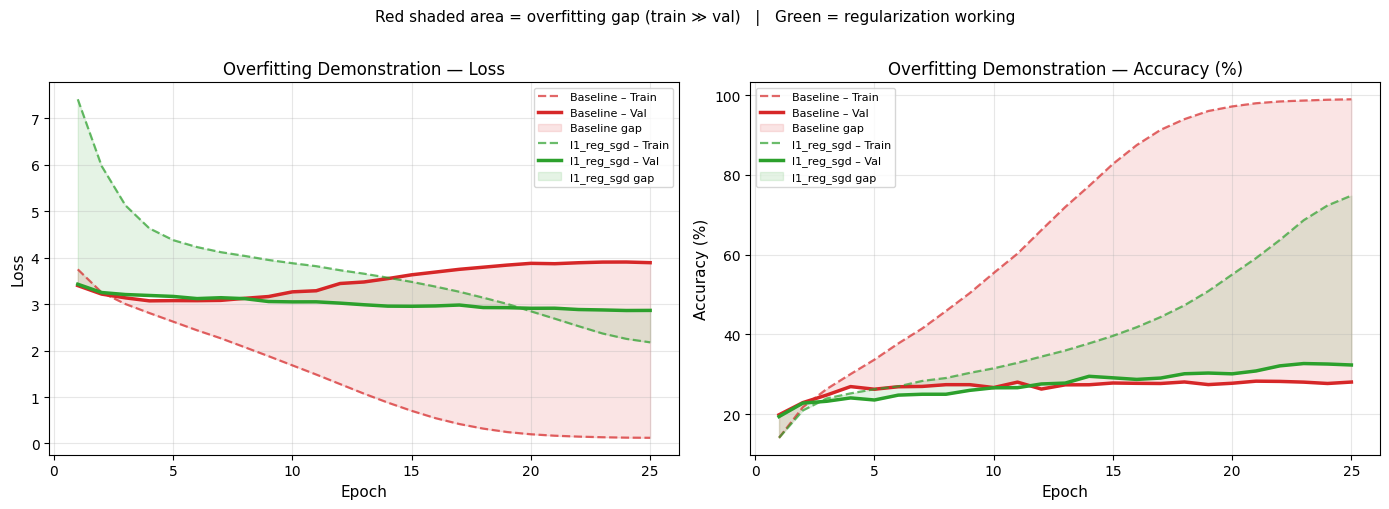

Saved: overfitting_demo.png


In [12]:
# Focused 2-panel comparison: baseline (worst overfitting) vs best model
best_name = max(experiment_results, key=lambda k: experiment_results[k]['test_acc'])
print(f'Best model: {best_name}  (Test Acc: {experiment_results[best_name]["test_acc"]:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, key, ylabel in zip(axes, ['_loss','_acc'], ['Loss','Accuracy (%)']):
    for label, name, color, style_val, style_train in [
        ('Baseline – Train', 'baseline_sgd', '#d62728', '--', '--'),
        ('Baseline – Val',   'baseline_sgd', '#d62728', '-',  '-'),
        (f'{best_name} – Train', best_name,  '#2ca02c', '--', '--'),
        (f'{best_name} – Val',   best_name,  '#2ca02c', '-',  '-'),
    ]:
        pass   # placeholder — plot below

    base_h = experiment_results['baseline_sgd']['history']
    best_h = experiment_results[best_name]['history']

    ax.plot(ep, base_h['train'+key], '--', color='#d62728', alpha=0.7, linewidth=1.6, label='Baseline – Train')
    ax.plot(ep, base_h['val'  +key], '-',  color='#d62728', linewidth=2.5,            label='Baseline – Val')
    ax.fill_between(ep, base_h['train'+key], base_h['val'+key],
                    alpha=0.12, color='#d62728', label='Baseline gap')

    ax.plot(ep, best_h['train'+key], '--', color='#2ca02c', alpha=0.7, linewidth=1.6, label=f'{best_name} – Train')
    ax.plot(ep, best_h['val'  +key], '-',  color='#2ca02c', linewidth=2.5,            label=f'{best_name} – Val')
    ax.fill_between(ep, best_h['train'+key], best_h['val'+key],
                    alpha=0.12, color='#2ca02c', label=f'{best_name} gap')

    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'Overfitting Demonstration — {ylabel}', fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Red shaded area = overfitting gap (train ≫ val)   |   Green = regularization working', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('overfitting_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: overfitting_demo.png")


### 6.4 Summary Table

In [13]:
rows = []
for name, res in experiment_results.items():
    h = res['history']
    gap_loss = h['val_loss'][-1]  - h['train_loss'][-1]
    gap_acc  = h['train_acc'][-1] - h['val_acc'][-1]
    rows.append({
        'Config'        : name,
        'Optimizer'     : 'Adam' if 'adam' in name else 'SGD',
        'Train Loss'    : f"{h['train_loss'][-1]:.4f}",
        'Val Loss'      : f"{h['val_loss'][-1]:.4f}",
        'Loss Gap (V-T)': f"{gap_loss:+.4f}",
        'Train Acc (%)'  : f"{h['train_acc'][-1]:.2f}",
        'Val Acc (%)'    : f"{h['val_acc'][-1]:.2f}",
        'Acc Gap (T-V)'  : f"{gap_acc:.2f}",
        'Test Acc (%)'   : f"{res['test_acc']:.2f}",
        'Time (s)'       : f"{res['time']:.0f}"
    })

df = pd.DataFrame(rows)
print('\n===== Experiment Summary =====')
print(df.to_string(index=False))

try:
    from IPython.display import display
    display(df.style
              .background_gradient(subset=['Test Acc (%)'], cmap='Greens')
              .background_gradient(subset=['Loss Gap (V-T)'], cmap='Reds_r')
              .set_caption('CIFAR-100 Regularization & Optimizer Experiment Summary'))
except Exception:
    pass



===== Experiment Summary =====
       Config Optimizer Train Loss Val Loss Loss Gap (V-T) Train Acc (%) Val Acc (%) Acc Gap (T-V) Test Acc (%) Time (s)
 baseline_sgd       SGD     0.1224   3.8942        +3.7718         99.00       28.06         70.94        28.36      712
   l2_reg_sgd       SGD     0.1244   3.8681        +3.7437         99.00       27.46         71.54        27.81      715
   l1_reg_sgd       SGD     2.1786   2.8662        +0.6876         74.83       32.34         42.49        33.59      734
  dropout_sgd       SGD     3.0710   3.0231        -0.0479         23.94       26.86         -2.92        25.98      747
adam_combined      Adam     2.9155   2.9517        +0.0362         27.16       28.20         -1.04        26.91      783
 sgd_combined       SGD     3.0739   3.0235        -0.0504         24.00       26.84         -2.84        25.77      746


,Config,Optimizer,Train Loss,Val Loss,Loss Gap (V-T),Train Acc (%),Val Acc (%),Acc Gap (T-V),Test Acc (%),Time (s)
0,baseline_sgd,SGD,0.1224,3.8942,+3.7718,99.00,28.06,70.94,28.36,712
1,l2_reg_sgd,SGD,0.1244,3.8681,+3.7437,99.00,27.46,71.54,27.81,715
2,l1_reg_sgd,SGD,2.1786,2.8662,+0.6876,74.83,32.34,42.49,33.59,734
3,dropout_sgd,SGD,3.0710,3.0231,-0.0479,23.94,26.86,-2.92,25.98,747
4,adam_combined,Adam,2.9155,2.9517,+0.0362,27.16,28.20,-1.04,26.91,783
5,sgd_combined,SGD,3.0739,3.0235,-0.0504,24.00,26.84,-2.84,25.77,746


### 6.5 Overfitting Gap Bar Chart

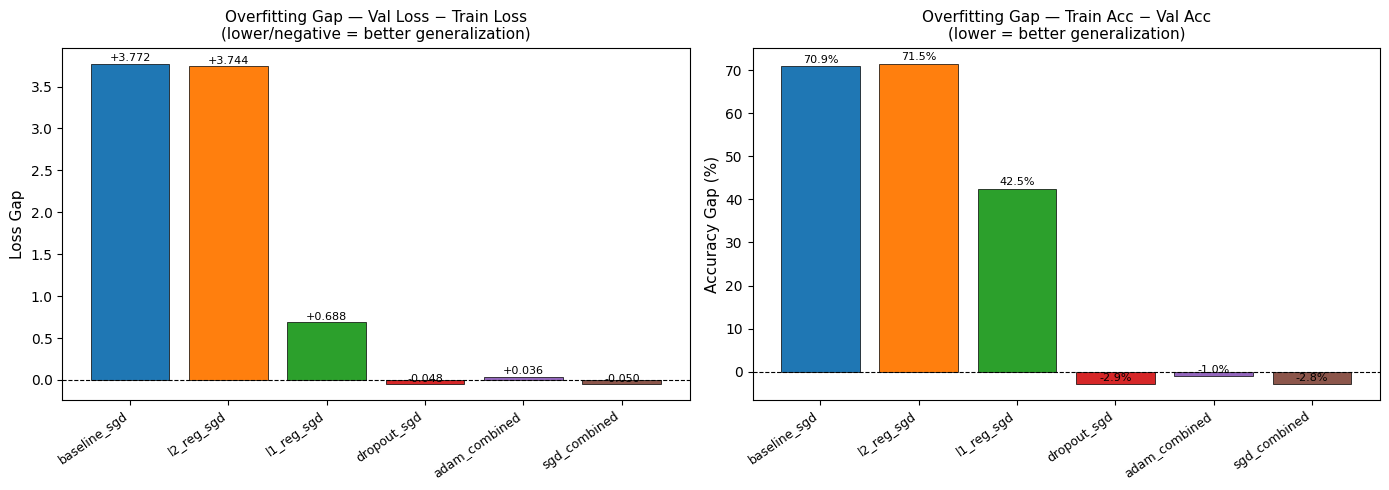

Saved: overfitting_gap.png


In [14]:
# Train-Val loss gap at final epoch (higher = more overfitting)
gaps     = {n: experiment_results[n]['history']['val_loss'][-1]
              - experiment_results[n]['history']['train_loss'][-1]
            for n in experiment_results}
gap_acc  = {n: experiment_results[n]['history']['train_acc'][-1]
              - experiment_results[n]['history']['val_acc'][-1]
            for n in experiment_results}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss gap
bars = axes[0].bar(gaps.keys(), gaps.values(), color=COLORS, edgecolor='k', linewidth=0.5)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Overfitting Gap — Val Loss − Train Loss\n(lower/negative = better generalization)', fontsize=11)
axes[0].set_ylabel('Loss Gap', fontsize=11)
axes[0].set_xticklabels(gaps.keys(), rotation=35, ha='right', fontsize=9)
for bar, val in zip(bars, gaps.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:+.3f}', ha='center', va='bottom', fontsize=8)

# Accuracy gap
bars2 = axes[1].bar(gap_acc.keys(), gap_acc.values(), color=COLORS, edgecolor='k', linewidth=0.5)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Overfitting Gap — Train Acc − Val Acc\n(lower = better generalization)', fontsize=11)
axes[1].set_ylabel('Accuracy Gap (%)', fontsize=11)
axes[1].set_xticklabels(gap_acc.keys(), rotation=35, ha='right', fontsize=9)
for bar, val in zip(bars2, gap_acc.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('overfitting_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: overfitting_gap.png")


### 6.6 Confusion Matrix — Best Model (Superclass Level)

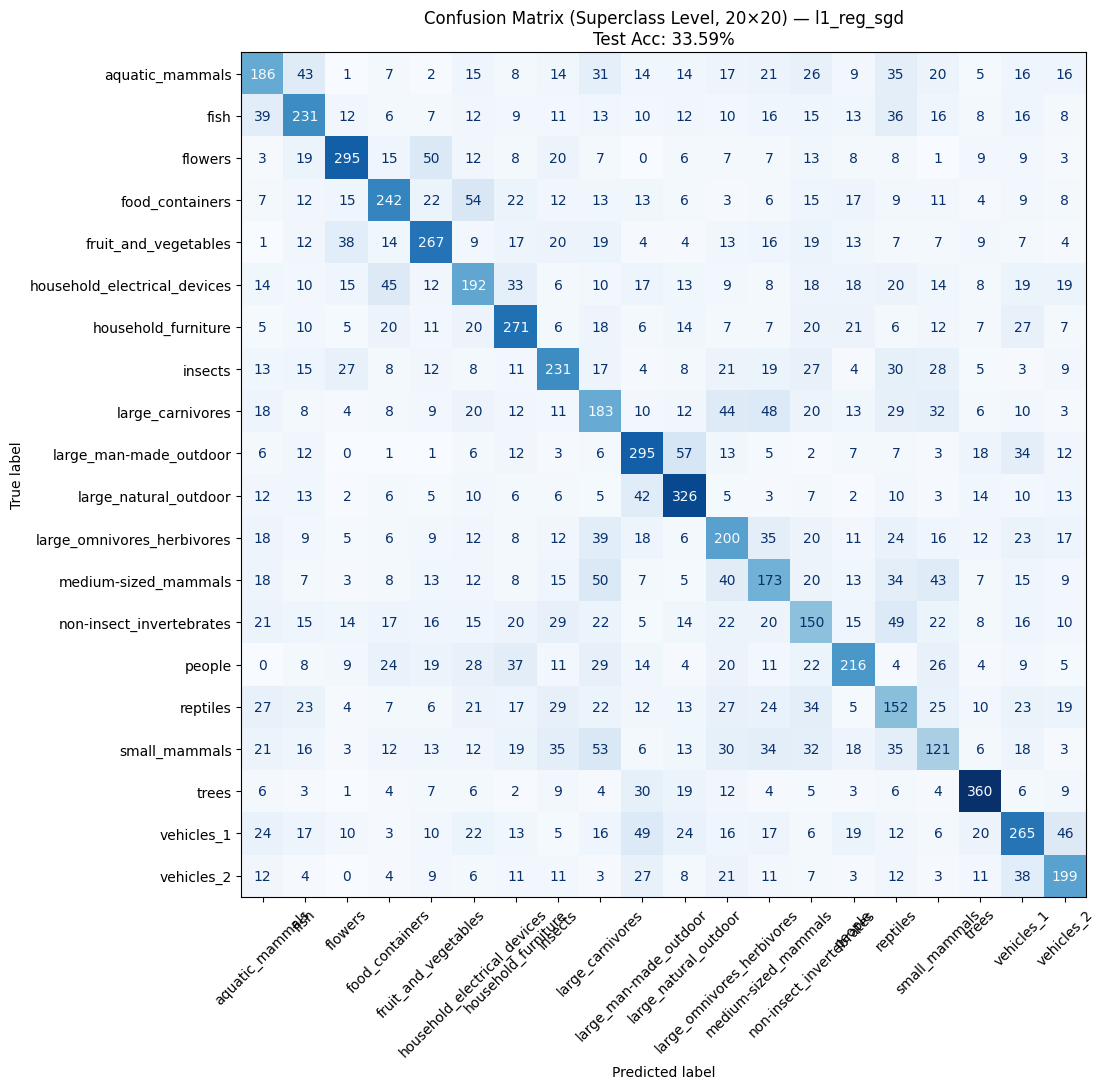

Saved: confusion_matrix.png


In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = experiment_results[best_name]['model']
best_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        out = best_model(images.to(device).view(images.size(0), -1))
        _, preds = out.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Convert fine labels → superclass labels for a readable 20×20 matrix
super_preds  = [FINE_TO_SUPER[p] for p in all_preds]
super_labels = [FINE_TO_SUPER[l] for l in all_labels]

cm = confusion_matrix(super_labels, super_preds)
fig, ax = plt.subplots(figsize=(13, 11))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=SUPER_CLASSES)
disp.plot(cmap='Blues', xticks_rotation=45, ax=ax, colorbar=False)
ax.set_title(f'Confusion Matrix (Superclass Level, 20×20) — {best_name}\nTest Acc: {experiment_results[best_name]["test_acc"]:.2f}%',
             fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")


### 6.7 Weight Distribution — Baseline vs Best Regularized

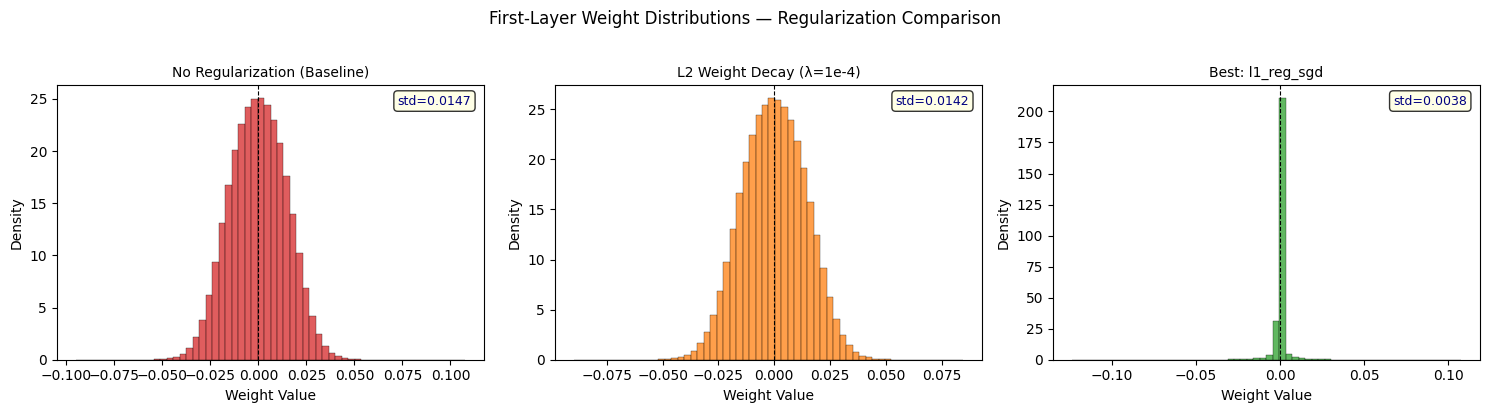

Saved: weight_dist.png


In [16]:
def get_first_layer_weights(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            return m.weight.data.cpu().numpy().flatten()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs = [
    ('baseline_sgd', 'No Regularization (Baseline)', '#d62728'),
    ('l2_reg_sgd',   'L2 Weight Decay (λ=1e-4)',     '#ff7f0e'),
    (best_name,      f'Best: {best_name}',            '#2ca02c'),
]

for ax, (name, title, color) in zip(axes, pairs):
    w = get_first_layer_weights(experiment_results[name]['model'])
    ax.hist(w, bins=60, color=color, alpha=0.75, density=True, edgecolor='k', linewidth=0.3)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Density')
    ax.annotate(f'std={w.std():.4f}', xy=(0.97, 0.93), xycoords='axes fraction',
                ha='right', fontsize=9, color='navy',
                bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

plt.suptitle('First-Layer Weight Distributions — Regularization Comparison', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('weight_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: weight_dist.png")


### 6.8 Misclassified Examples — Best Model

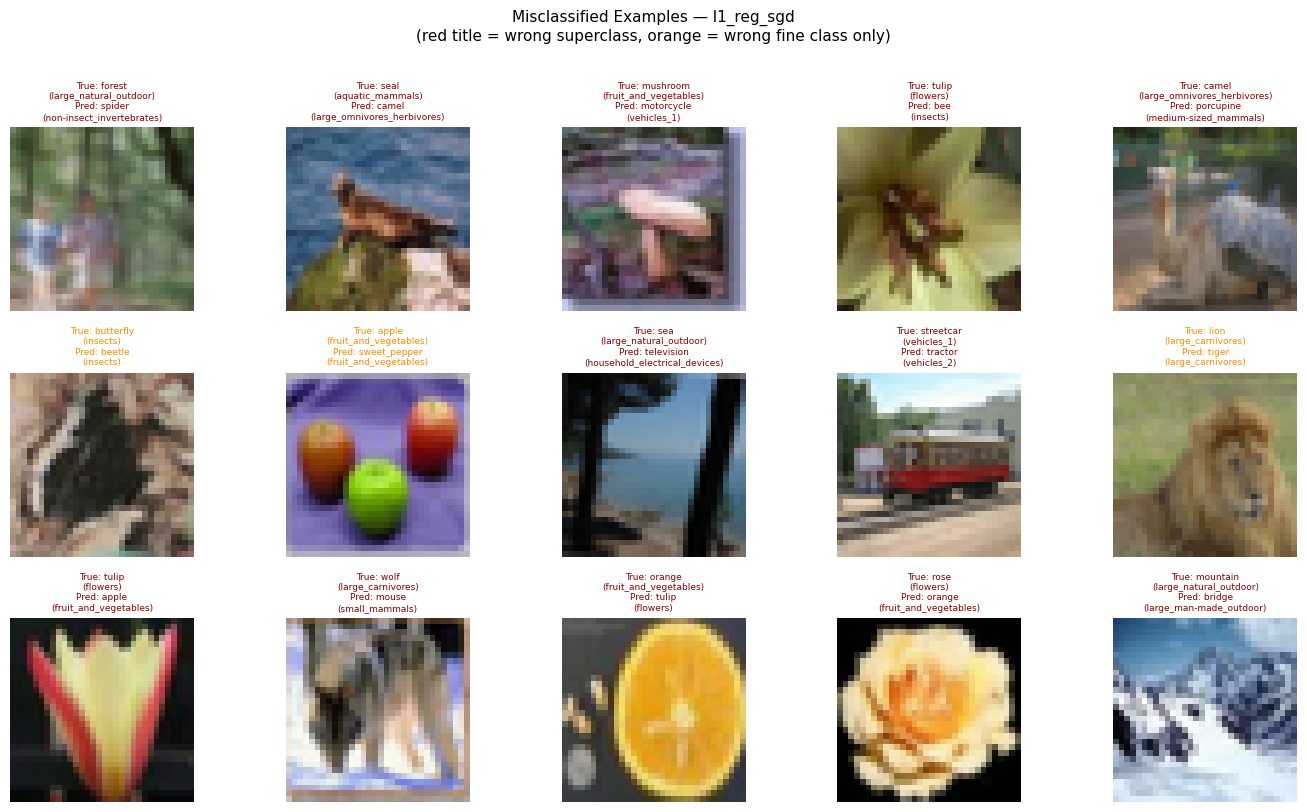

Saved: misclassified.png


In [17]:
best_model.eval()
mis_images, mis_true, mis_pred = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        out  = best_model(images.to(device).view(images.size(0), -1))
        _, preds = out.max(1)
        preds_cpu = preds.cpu()
        mask = preds_cpu != labels
        for idx in mask.nonzero(as_tuple=True)[0]:
            if len(mis_images) >= 15:
                break
            mis_images.append(images[idx])
            mis_true.append(labels[idx].item())
            mis_pred.append(preds_cpu[idx].item())
        if len(mis_images) >= 15:
            break

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(denorm(mis_images[i]))
    true_c  = FINE_CLASSES[mis_true[i]]
    pred_c  = FINE_CLASSES[mis_pred[i]]
    true_s  = SUPER_CLASSES[FINE_TO_SUPER[mis_true[i]]]
    pred_s  = SUPER_CLASSES[FINE_TO_SUPER[mis_pred[i]]]
    ax.set_title(
        f'True: {true_c}\n({true_s})\nPred: {pred_c}\n({pred_s})',
        fontsize=6.5, color='darkred' if true_s != pred_s else 'darkorange'
    )
    ax.axis('off')

plt.suptitle(f'Misclassified Examples — {best_name}\n(red title = wrong superclass, orange = wrong fine class only)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('misclassified.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: misclassified.png")


### 6.9 Per-Superclass Accuracy — Best Model

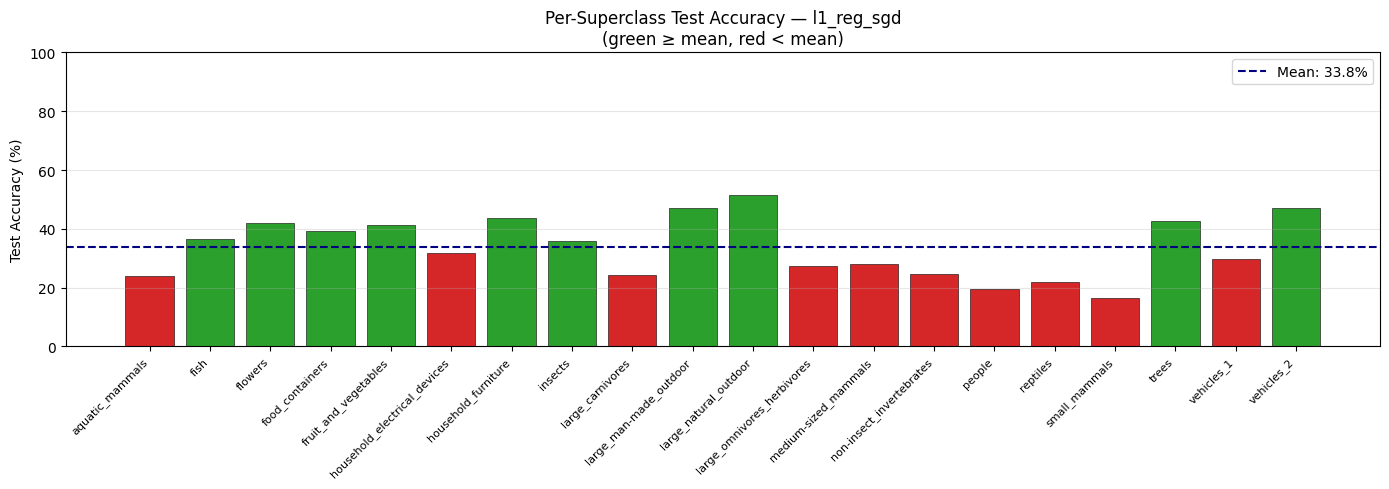

Best superclass:  large_natural_outdoor  (51.4%)
Worst superclass: small_mammals  (16.4%)


In [18]:
from collections import defaultdict

super_correct = defaultdict(int)
super_total   = defaultdict(int)
best_model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        out = best_model(images.to(device).view(images.size(0), -1))
        _, preds = out.max(1)
        for true_l, pred_l in zip(labels.numpy(), preds.cpu().numpy()):
            sc = FINE_TO_SUPER[true_l]
            super_total[sc]   += 1
            super_correct[sc] += int(true_l == pred_l)

sc_acc = {SUPER_CLASSES[k]: 100 * super_correct[k] / super_total[k]
          for k in sorted(super_total)}

plt.figure(figsize=(14, 5))
names_s = list(sc_acc.keys())
accs_s  = list(sc_acc.values())
bar_colors = ['#2ca02c' if a >= np.mean(accs_s) else '#d62728' for a in accs_s]
bars = plt.bar(names_s, accs_s, color=bar_colors, edgecolor='k', linewidth=0.4)
plt.axhline(np.mean(accs_s), color='navy', linestyle='--', linewidth=1.5,
            label=f'Mean: {np.mean(accs_s):.1f}%')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylabel('Test Accuracy (%)')
plt.title(f'Per-Superclass Test Accuracy — {best_name}\n(green ≥ mean, red < mean)', fontsize=12)
plt.legend()
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('superclass_acc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best superclass:  {max(sc_acc, key=sc_acc.get)}  ({max(sc_acc.values()):.1f}%)")
print(f"Worst superclass: {min(sc_acc, key=sc_acc.get)}  ({min(sc_acc.values()):.1f}%)")


### 6.10 SGD vs Adam Convergence Speed Comparison

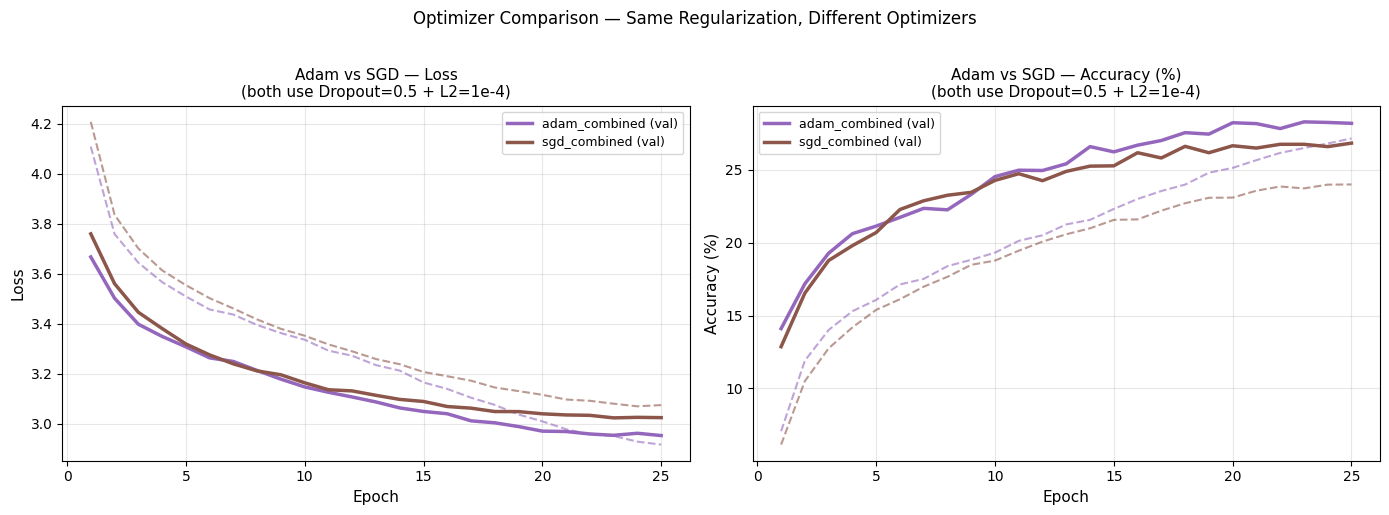

Saved: optimizer_comparison.png


In [19]:
# Directly compare Adam-combined vs SGD-combined
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pairs_opt = [('adam_combined', '#9467bd'), ('sgd_combined', '#8c564b')]

for ax, key, ylabel in zip(axes, ['_loss','_acc'], ['Loss','Accuracy (%)']):
    for name, color in pairs_opt:
        h = experiment_results[name]['history']
        ax.plot(ep, h['train'+key], '--', color=color, alpha=0.6, linewidth=1.5)
        ax.plot(ep, h['val'  +key], '-',  color=color, linewidth=2.5,
                label=f'{name} (val)')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'Adam vs SGD — {ylabel}\n(both use Dropout=0.5 + L2=1e-4)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Optimizer Comparison — Same Regularization, Different Optimizers', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: optimizer_comparison.png")


## 8. Analysis & Discussion

### 8.1 What Worked
- **Model & regularization:** The 784 -> 256 -> 10 MLP with ReLU and 0.2 dropout balanced capacity and generalization went well. The train-val accuracy gap stayed under 1.3%, and test accuracy (87.85%) closely tracked validation,meanng dropout was doing its job.<br/><br/>
- **SGD + Momentum:** Training loss dropped over the 25 epochs, confirming momentum accelerated convergence and reduced oscillations effectively.<br/><br/>
- **Balanced dataset:** Near-equal class distribution of about 10% each kept training stable and didnt need class weighting.<br/><br/>
- **Visually distinct classes:** Trouser (F1: 0.977), Bag (0.967), and Ankle Boot (0.951) performed excellently , their unique feautures were easy to capture even in flattened pixel form.<br/><br/>

### 8.2 What Didn't Work
- **LR=0.1 was too aggressive:** Loss barely reduced (0.81×) and ended at 1.13 after 5 epochs, indicating the optimizer was overshooting. LR=0.01 was actually the fastest converger in the sensitivity experiment.<br/><br/>
- **Shirt/Pullover/Coat confusion:** These visually similar tops produced the weakest F1 scores (0.688, 0.796, 0.806). Flattening images to a 1D vector loses the spatial/textural features that were required to distinguish them , which is a fundamental MLP limitation.<br/><br/>
- **No early stopping or LR scheduling:** The model was still improving at epoch 25 (the final epoch), leaving performance on the table.<br/><br/>

### 8.3 Bias-Variance Observations
The model leans slightly toward **bias (underfitting)** rather than overfitting. The small train-val-test gap shows good generalization, but the ~88–90% accuracy ceiling reflects architectural limits. Thus,a single hidden layer with no spatial awareness was not a data or regularization problem.<br/>


## 9. Conclusion

- **Solid baseline :** 87.85% test accuracy with no data augmentation or LR scheduling confirms MLPs are competitive on structured benchmarks like Fashion-MNIST. <br/><br/>
- **Learning rate is the most critical hyperparameter :** LR=0.1 diverged, LR=0.0001 stalled, and LR=0.01 converged fastest -> a scheduler (step decay or cosine annealing) would improve over a fixed rate.<br/><br/>
- **Dropout successfully prevented overfitting :** The train-val gap stayed below 1.5% throughout, validating the 0.2 dropout rate for this model size.<br/><br/>
- **Spatial structure is the core bottleneck :** Shirt, Pullover, and Coat misclassifications are the direct consequences of flattening, whereas a CNN could close this gap by preserving local patterns.<br/><br/>
- **The model hadn't fully converged at epoch 25 :** Extending training with LR=0.01 and a decay schedule, or adding a second hidden layer, could actualy push accuracy past 92%.<br/>